<Axes: >

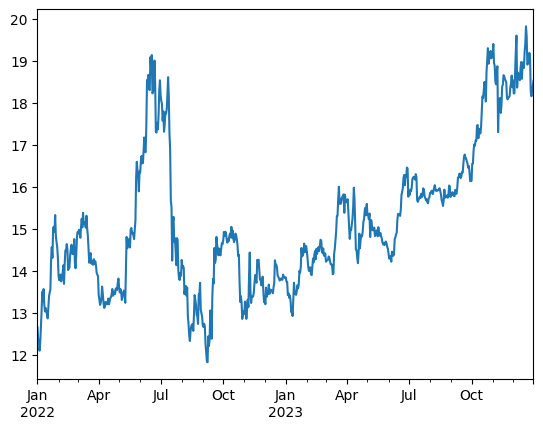

In [148]:
import bt
import pandas as pd

data = bt.get("btc-usd, eth-usd", start="2022-01-01", end="2024-01-01")
data["ratio"] = data.btcusd / data.ethusd
data["ratio"].plot()

In [149]:
from collections import defaultdict

cash = 100000
pnl = []
pos = defaultdict(float)
window = 180
for i, row in data.iterrows():
    mean = data["ratio"][:i].tail(window).mean()
    std = data["ratio"][:i].tail(window).std()
    tolerance = std * 0.1

    if row["ratio"] < mean - 2 * std and pos["btcusd"] == 0:
        cash -= 1 * row["btcusd"]
        pos["btcusd"] = row["btcusd"]
    if row["ratio"] > mean + 2 * std and pos["ethusd"] == 0:
        cash -= 10 * row["ethusd"]
        pos["ethusd"] = row["ethusd"]

    r = cash
    if pos["btcusd"] > 0:
        r += 1 * (row["btcusd"] - pos["btcusd"])
        if abs(row["ratio"] - mean) < tolerance:
            cash += 1 * row["btcusd"]
            pos["btcusd"] = 0
    if pos["ethusd"] > 0:
        r += 10 * (row["ethusd"] - pos["ethusd"])
        if abs(row["ratio"] - mean) < tolerance:
            cash += 10 * row["ethusd"]
            pos["ethusd"] = 0
    pnl.append(r)
returns = pd.Series(pnl, index=data.index).pct_change()

/home/adam/investing/backtest/pyfolio/plotting.py:662: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-2.692%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2022-01-01
End date,2023-12-31
Total months,34
,Backtest
Annual return,-2.692%
Cumulative returns,-7.601%
Annual volatility,34.89%
Sharpe ratio,0.10
Calmar ratio,-0.10
Stability,0.10
Max drawdown,-27.107%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,27.11,2022-01-20,2022-01-22,2022-02-10,16
1,24.47,2022-05-25,2022-06-18,2023-04-18,235
2,20.61,2023-06-21,2023-10-12,NaT,NaN
3,NaN,NaT,NaT,NaT,NaN
4,NaN,NaT,NaT,NaT,NaN


ConversionError: Failed to convert value(s) to axis units: (NaT, Timestamp('2023-12-31 00:00:00'))

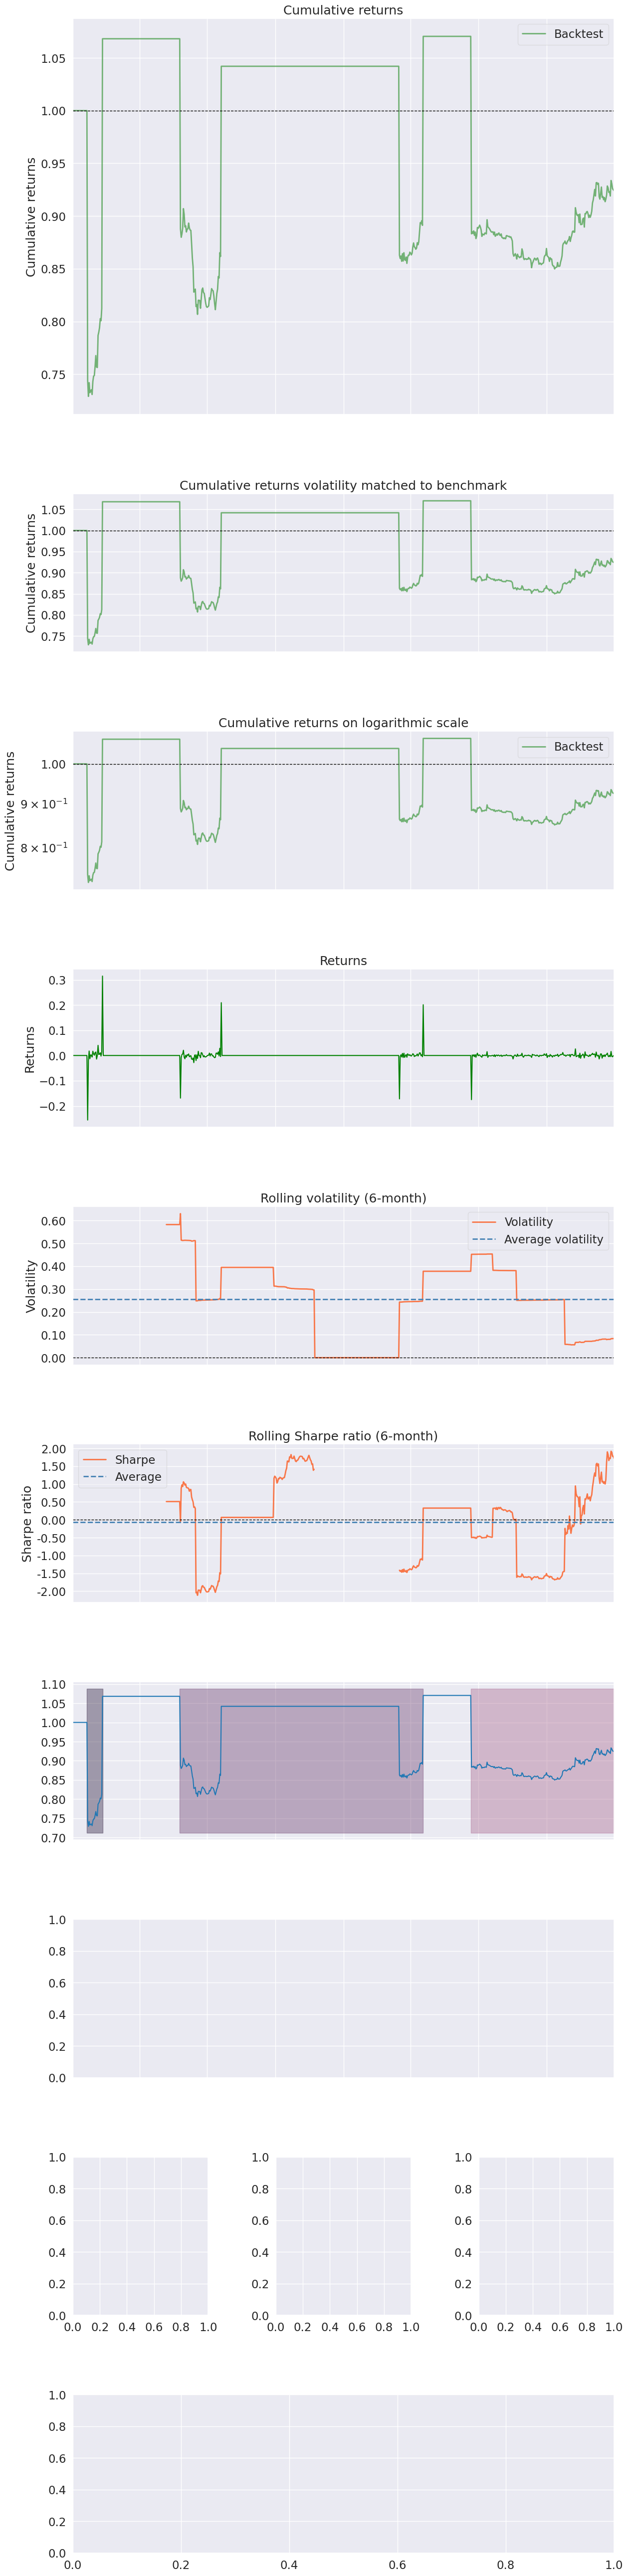

In [150]:
import pyfolio as pf

# return_csv = pd.read_csv('./return.csv', index_col=0, parse_dates=True, header=None)[1]
# pos = pd.read_csv('./pos.csv',index_col=0, parse_dates=True)
# tx = pd.read_csv('./test_txn.csv',index_col=0, parse_dates=True)
# return_csv2 = pd.read_csv('./return2.csv', index_col=0, parse_dates=True, header=None)[1]
pf.create_returns_tear_sheet(returns)